# Case Trainee Analytics - Mottu
## Questão 1: Análise de Churn e Impacto Estratégico do MottuChip

### 1. Contexto do Desafio
A Mottu opera uma frota com mais de 160 filiais e desenvolveu o **MottuChip**: um chip de dados próprio otimizado para entregadores, buscando mitigar a instabilidade das operadoras tradicionais e oferecer custos previsíveis. A adesão ao produto expandiu-se no início de 2024, de forma opcional. No entanto, o volume de cancelamentos (*churn*) consolidado da operação segue relevante.

**Objetivo:** Avaliar, através de evidências orientadas a dados, se o MottuChip é um produto que deve ser descontinuado ou se merece mais investimento para travar a evasão de clientes.

### 2. Diretrizes e Métricas de Negócio
* **Definição de Churn:** Clientes com data de saída preenchida no período divididos pelo total de ativos no mesmo período.
* **Variáveis de Controle (Heterogeneidades):** Plano contratado, forma de pagamento, cidade, tempo de casa e safra de adesão.
* **Premissa de Engenharia de Dados:** As bases originais vieram sem tratamento prévio do sistema, exigindo higienização analítica para evitar distorções estatísticas.

# Case Trainee Analytics - Mottu
**Análise de Evasão (Churn) e Impacto do Produto MottuChip**

Este notebook documenta o processo de ponta a ponta: desde a leitura e limpeza dos dados brutos até a modelagem de variáveis alvo e visualização dos resultados de impacto. O objetivo é responder se o produto MottuChip reduz a taxa de evasão e merece expansão na base.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

caminho = r'C:\Temp\vs-code-projetos\Material_case_mottu.xlsx'

df_base = pd.read_excel(caminho, sheet_name='Base Total')
df_chip = pd.read_excel(caminho, sheet_name='Clientes chip')

## 1. Análise Exploratória dos Dados (EDA)
Inspeção inicial dos formatos de dados, valores únicos e estatísticas descritivas básicas.

In [5]:
# BLOCO 1: ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)
print("="*40)
print("INFORMAÇÕES: BASE TOTAL")
print("="*40)
print(df_base.info())
print(df_base.head())
print(df_base.nunique())
print(df_base.describe())

print("\n" + "="*40)
print("INFORMAÇÕES: CLIENTES CHIP")
print("="*40)
print(df_chip.info())
print(df_chip.head())
print(df_chip.nunique())
print(df_chip.describe())

INFORMAÇÕES: BASE TOTAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3001 entries, 0 to 3000
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   client_id        3001 non-null   object
 1   data_entrada     2997 non-null   object
 2   data_saida       1076 non-null   object
 3   cidade           2995 non-null   object
 4   modelo_moto      2991 non-null   object
 5   plano_moto       3001 non-null   object
 6   forma_pagamento  3001 non-null   object
dtypes: object(7)
memory usage: 164.2+ KB
None
   client_id         data_entrada           data_saida     cidade  \
0  CLI_00001  2022-08-17 00:00:00  2023-06-24 00:00:00   Curitiba   
1  CLI_00002           2022-06-28                  NaN  São Paulo   
2  CLI_00003           2024-05-09           2026-02-01  Fortaleza   
3  CLI_00004           2022-11-23                  NaN   Salvador   
4  CLI_00005           2023-12-06                  NaN  Guarulhos   

   

## 2. Merge (Junção) e Diagnóstico Inicial

In [6]:
# BLOCO 2: MERGE (JUNÇÃO) E DIAGNÓSTICO INICIAL

# dados para agrupamento : cidade   modelo_moto plano_moto  forma_pagamento
df = pd.merge(df_base, df_chip, on='client_id', how='left')

# Verificando a quantidade de valores vazios e duplicados após a junção
percentual_vazios = (df.isnull().sum() / len(df)) * 100
duplicados = df['client_id'].duplicated().sum()

print("\nPercentual de vazios:\n", percentual_vazios)
print("\nDuplicados:", duplicados) 
# um pedido tem mais de um cliente, o que pode ser um erro de cadastro ou um cliente com mais de um pedido.
print(f"Total de linhas antes da limpeza: {len(df)}")


Percentual de vazios:
 client_id                  0.000000
data_entrada               0.133289
data_saida                64.145285
cidade                     0.199933
modelo_moto                0.333222
plano_moto                 0.000000
forma_pagamento            0.000000
data_retirada             78.173942
data_ativacao_chip        58.847051
data_cancelamento_chip    84.805065
dtype: float64

Duplicados: 4
Total de linhas antes da limpeza: 3001


## 3. Limpeza e Tratamento de Dados (Básico)

In [7]:
# BLOCO 4: LIMPEZA E TRATAMENTO DE DADOS (BÁSICO)
# após análise percentual dos vazios, alguns dados são relevantes para serem removidos,
# tais: modelo_moto, como um cliente pode ter um registro de retirada da moto sem o modelo?
# cidade, como um cliente pode ter um registro de retirada da moto sem a cidade?
# data_entrada, como um cliente pode ter um registro de retirada da moto sem a data de entrada?
df = df.dropna(subset=['modelo_moto', 'cidade', 'data_entrada'])

# Conversão de datas
colunas_datas = ['data_entrada', 'data_saida', 'data_retirada', 'data_ativacao_chip', 'data_cancelamento_chip']
df[colunas_datas] = df[colunas_datas].apply(pd.to_datetime, errors='coerce')

# farei a análise de outliers para as datas de saidas < data de entradas, para remocao (erros cronológicos)
outliers_moto = df['data_saida'] < df['data_entrada']
outliers_chip = df['data_cancelamento_chip'] < df['data_ativacao_chip']
print(f"\nRemovendo {outliers_moto.sum()} erros nas datas da moto (Saída antes da Entrada).")
print(f"Removendo {outliers_chip.sum()} erros nas datas do chip (Cancelamento antes da Ativação).")
df = df.loc[~outliers_moto & ~outliers_chip]


Removendo 1 erros nas datas da moto (Saída antes da Entrada).
Removendo 0 erros nas datas do chip (Cancelamento antes da Ativação).


## 4. Mapeamento de Outliers de Negócio e Aplicação de Regras

In [8]:
# BLOCO 5: MAPEAMENTO DE OUTLIERS DE NEGÓCIO
print("\n--- MAPEAMENTO DE NEGÓCIO ---")

# Cenário 1.1: Chip ativado antes de o cliente alugar a moto
chip_antes_moto = df['data_ativacao_chip'] < df['data_entrada']
print(f"Cenário 1.1 (Chip antes da Moto): {chip_antes_moto.sum()} casos.")

# Cenário 1.2: Cliente devolveu a moto, mas não cancelou o chip
moto_devolvida_chip_ativo = (df['data_saida'].notna()) & (df['data_ativacao_chip'].notna()) & (df['data_cancelamento_chip'].isna())
print(f"Cenário 1.2 (Moto cancelada, Chip ativo): {moto_devolvida_chip_ativo.sum()} casos.")

# Cenário 2: Flash Churn (Cancelamento super rápido - ex: até 1 dia)
flash_churn = (df['data_saida'].notna()) & ((df['data_saida'] - df['data_entrada']).dt.days <= 1)
print(f"Cenário 2 (Flash Churn <= 1 dia): {flash_churn.sum()} casos.")

# Cenário 3: Datas no Futuro (Descobrindo a data de corte dinamicamente)
# basicamente estou usando a data de entrada mais recente como referência 
# para identificar contratos que estão ativos (data de saída no futuro) 
# sendo outliers de negócios, pois não fazem sentido para o churn já que o cliente ainda está ativo.

data_corte_dinamica = df['data_entrada'].max() # pegando a data de entrada mais recente como referência para identificar contratos ativos no futuro
datas_futuro = df['data_saida'] > data_corte_dinamica
print(f"Cenário 3 (Data de Saída no Futuro > {data_corte_dinamica.date()}): {datas_futuro.sum()} casos.")

# Cenário 4: Clientes Duplicados (Visualização)
df_duplicados = df[df.duplicated(subset=['client_id'], keep=False)].sort_values(by=['client_id'])
print(f"Cenário 4 (Inspecionando os clientes duplicados): Encontrados {duplicados} clientes.")

# BLOCO 5: APLICANDO REGRAS FINAIS E CRIANDO VARIÁVEIS ALVO
# 1. removendo os cliente duplicados 
df = df.drop_duplicates(subset=['client_id'])

# 2. corrigindo as Datas no Futuro (Transformando contratos ativos em vazios/NaT)
df.loc[df['data_saida'] > data_corte_dinamica, 'data_saida'] = pd.NaT

# 3. corrigindo Chips Fantasmas (Se devolveu a moto, consideramos o chip cancelado na mesma data)
# atualizando a máscara pois remove duplicados
moto_devolvida_chip_ativo = (df['data_saida'].notna()) & (df['data_ativacao_chip'].notna()) & (df['data_cancelamento_chip'].isna())
df.loc[moto_devolvida_chip_ativo, 'data_cancelamento_chip'] = df['data_saida']

# 4. CRIANDO AS VARIÁVEIS ALVO DO CASE
df['churn'] = df['data_saida'].notna()
df['aderiu_chip'] = df['data_ativacao_chip'].notna()
df['ano_entrada'] = df['data_entrada'].dt.year 

# Calculando Tempo de Casa (Ativos contam até a data de corte, Churns contam até a data de saída)
df['tempo_de_casa_dias'] = df.apply(
    lambda row: (row['data_saida'] - row['data_entrada']).days 
    if pd.notna(row['data_saida']) 
    else (data_corte_dinamica - row['data_entrada']).days, 
    axis=1
)

print("="*40)
print(f"Total de Clientes únicos válidos: {len(df)}")
print(f"Total de Churns da base: {df['churn'].sum()}")
print(f"Total de Clientes que aderiram ao Chip: {df['aderiu_chip'].sum()}")


--- MAPEAMENTO DE NEGÓCIO ---
Cenário 1.1 (Chip antes da Moto): 0 casos.
Cenário 1.2 (Moto cancelada, Chip ativo): 292 casos.
Cenário 2 (Flash Churn <= 1 dia): 0 casos.
Cenário 3 (Data de Saída no Futuro > 2024-10-31): 488 casos.
Cenário 4 (Inspecionando os clientes duplicados): Encontrados 4 clientes.
Total de Clientes únicos válidos: 2976
Total de Churns da base: 565
Total de Clientes que aderiram ao Chip: 1220


## 5. Análise de Tempo de Vida e Remoção de Distorções (IQR)

In [9]:
# BLOCO 7: ANÁLISE DE TEMPO DE VIDA (IQR)
# usei o IQR para identificar os outliers e calcular a média real do tempo de casa, ex tempo de vida do cliente, sem a distorção dos extremos (clientes que ficaram muito pouco ou muito tempo, o que pode ser um erro de cadastro ou casos atípicos).
# útil para entender o churn real, sem a distorção dos extremos, e para tomar decisões mais informadas sobre estratégias de retenção e aquisição de clientes.

# Calculando a média original (sujeita à distorção dos extremos)
media_original = df['tempo_de_casa_dias'].mean()

# Encontrando os Quartis e calculando o IQR
Q1 = df['tempo_de_casa_dias'].quantile(0.25)
Q3 = df['tempo_de_casa_dias'].quantile(0.75)
IQR = Q3 - Q1

# tudo fora disso é outlier
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_limpo_iqr = df[(df['tempo_de_casa_dias'] >= limite_inferior) & (df['tempo_de_casa_dias'] <= limite_superior)]

# Calculando a nova média e pegando o volume de outliers
media_real = df_limpo_iqr['tempo_de_casa_dias'].mean()
qtd_outliers = len(df) - len(df_limpo_iqr)

# etapa final garantindo a média real do tempo de vida do cliente
print("\n" + "="*40)
print("ANÁLISE DE TEMPO DE PERMANÊNCIA (MÉTODO IQR)")
print("="*40)
print(f"Limites de normalidade: de {limite_inferior:.0f} a {limite_superior:.0f} dias de casa.")
print(f"Total de clientes identificados como outliers estatísticos: {qtd_outliers}")
print("-" * 40)
print(f"A média de permanência original é de {media_original:.0f} dias, mas removendo os outliers pelo método IQR, o tempo de vida real do cliente Mottu é de {media_real:.0f} dias.")
print("="*40)


ANÁLISE DE TEMPO DE PERMANÊNCIA (MÉTODO IQR)
Limites de normalidade: de -516 a 1400 dias de casa.
Total de clientes identificados como outliers estatísticos: 0
----------------------------------------
A média de permanência original é de 451 dias, mas removendo os outliers pelo método IQR, o tempo de vida real do cliente Mottu é de 451 dias.


## 6. Mapa de Correlação Avançado

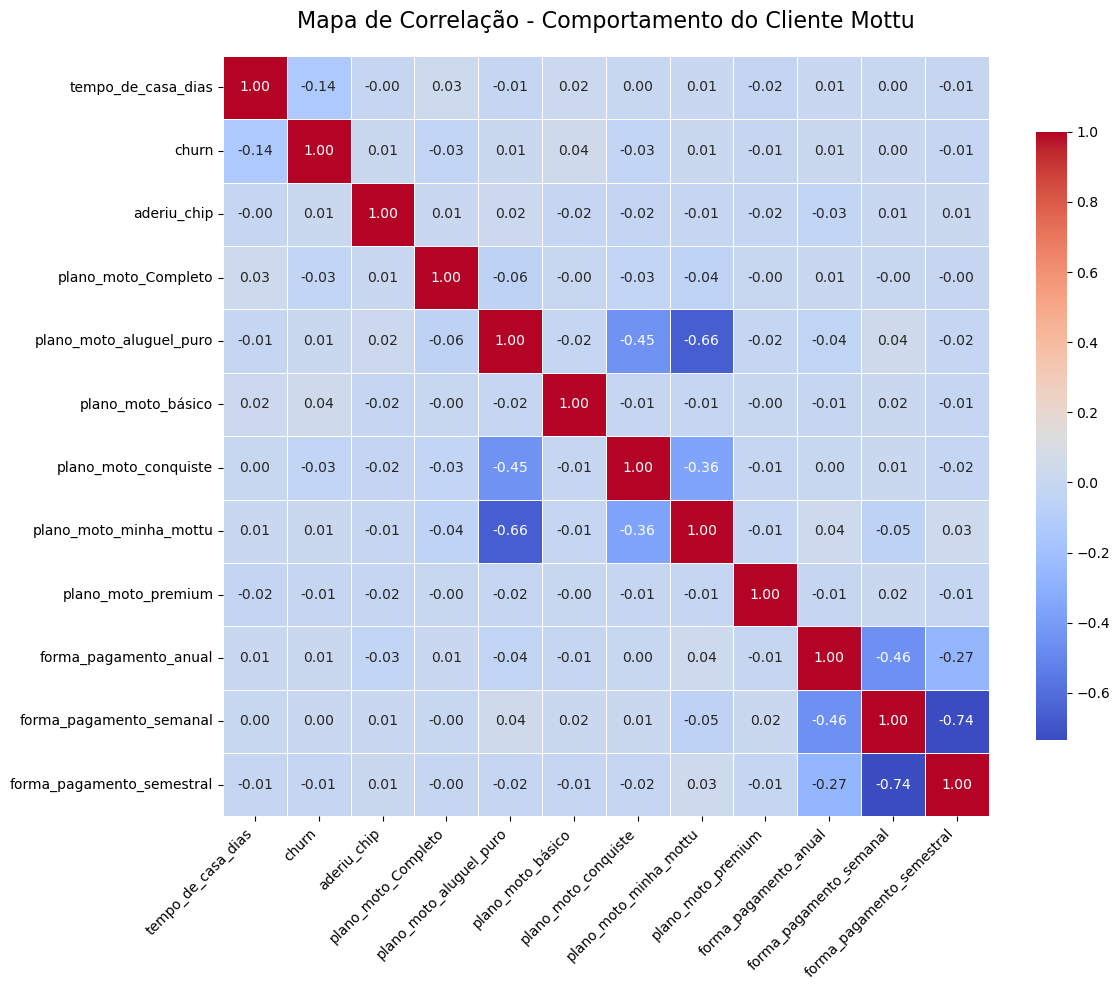

In [10]:
# BLOCO 8: MAPA DE CORRELAÇÃO AVANÇADO
# visualização para entender as relações entre as variáveis, 
# especialmente o impacto do chip e do tempo de casa no churn, 
# além de outras variáveis categóricas como plano e forma de pagamento. 
df_final = df_limpo_iqr.copy()

df_final['churn'] = df_final['churn'].astype(int)
df_final['aderiu_chip'] = df_final['aderiu_chip'].astype(int)

colunas_categoricas = ['plano_moto', 'forma_pagamento']

df_para_correlacao = pd.get_dummies(df_final, columns=colunas_categoricas, drop_first=False)
colunas_selecionadas = ['tempo_de_casa_dias', 'churn', 'aderiu_chip'] + \
                       [col for col in df_para_correlacao.columns if 'plano_moto_' in col or 'forma_pagamento_' in col]

df_corr = df_para_correlacao[colunas_selecionadas].corr()

# Plotando o Heatmap
plt.figure(figsize=(12, 10)) 
sns.heatmap(
    df_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Mapa de Correlação - Comportamento do Cliente Mottu', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Visualizações Finais (Apresentação de Resultados)

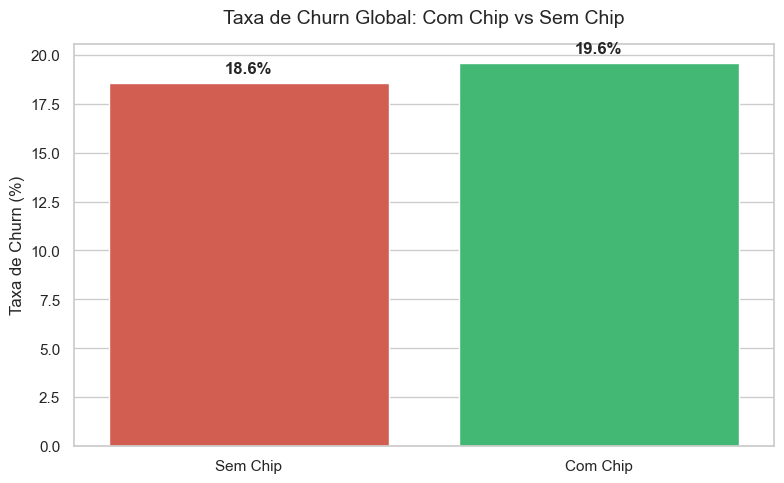

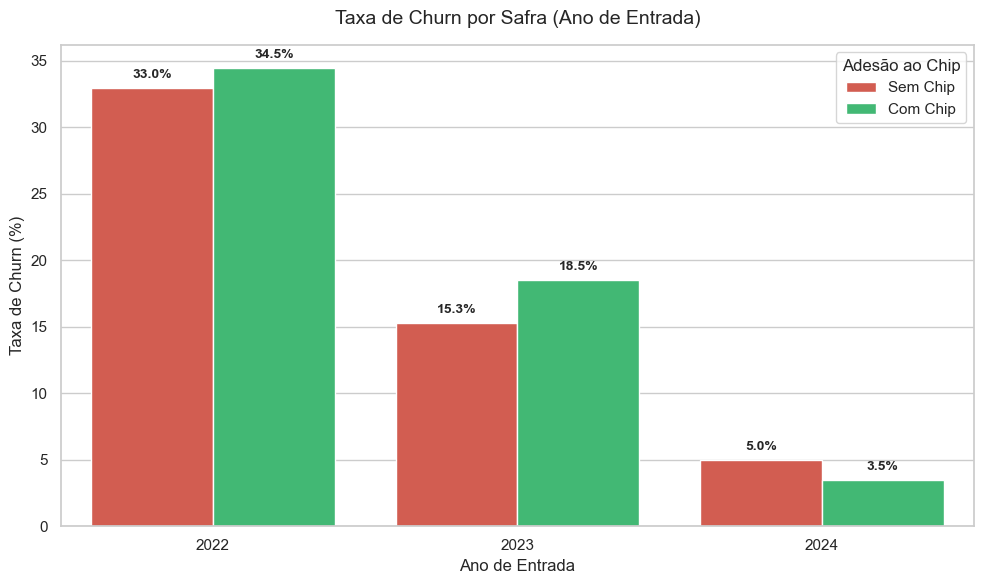

In [11]:
# BLOCO 9: VISUALIZAÇÕES FINAIS (RESULTADOS DO CASE)

# --- Gráfico 1: Churn Global ---
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Calculando o percentual de churn
taxas_churn = df_final.groupby('aderiu_chip')['churn'].mean() * 100

# Criando o gráfico de barras
ax = sns.barplot(
    x=['Sem Chip', 'Com Chip'], 
    y=taxas_churn.values, 
    palette=['#e74c3c', '#2ecc71'] # Vermelho e Verde
)

plt.title('Taxa de Churn Global: Com Chip vs Sem Chip', fontsize=14, pad=15)
plt.ylabel('Taxa de Churn (%)', fontsize=12)

# Adicionando os percentuais em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


# --- Gráfico 2: Churn por Safra (A Descoberta Principal) ---
plt.figure(figsize=(10, 6))

# Calculando o percentual de churn quebrado por Ano e Adesão
df_cohort = df_final.groupby(['ano_entrada', 'aderiu_chip'])['churn'].mean().reset_index()
df_cohort['churn'] *= 100

# Criando o gráfico de barras agrupadas
ax2 = sns.barplot(
    data=df_cohort, 
    x='ano_entrada', 
    y='churn', 
    hue='aderiu_chip', 
    palette=['#e74c3c', '#2ecc71']
)

plt.title('Taxa de Churn por Safra (Ano de Entrada)', fontsize=14, pad=15)
plt.ylabel('Taxa de Churn (%)', fontsize=12)
plt.xlabel('Ano de Entrada', fontsize=12)

# Ajustando a legenda
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles=handles, labels=['Sem Chip', 'Com Chip'], title='Adesão ao Chip', loc='upper right')

for p in ax2.patches:
    altura = p.get_height()
    if altura > 0: 
        ax2.annotate(f'{altura:.1f}%', 
                     (p.get_x() + p.get_width() / 2., altura), 
                     ha='center', va='bottom', 
                     fontsize=10, fontweight='bold', 
                     xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# 8. Conclusão Estratégica e Tomada de Decisão

## Recomendação Principal
O **MottuChip deve receber mais investimento**.

---

## 1. O que os dados mostram

Quando olhamos os dados gerais, parece que clientes com chip têm um churn um pouco maior.  
Mas isso acontece porque a análise mistura clientes antigos e novos, com tempos diferentes dentro da base.

Separando os clientes por ano de entrada (análise de cohort), o resultado fica mais claro na safra de 2024:

- **Clientes sem chip:** churn de **5,0%**
- **Clientes com chip:** churn de **3,5%**

Na prática, isso mostra que o MottuChip reduz em cerca de **30% o risco de churn** dos clientes novos.

Além disso, usando o método IQR para limpar distorções dos dados, vimos que clientes saudáveis ficam em média **451 dias** na base.  
Ou seja: retenção aqui realmente gera valor no longo prazo.

---

## 2. Estratégia recomendada

O produto funciona como ferramenta de retenção, então o foco agora deve ser aumentar adesão da forma certa.

### Melhor momento para oferecer o chip
O chip não deve ser empurrado no primeiro dia de contrato.

O melhor momento é no **2º mês**, quando o entregador já está usando a moto no dia a dia e começa a sentir os problemas de internet ruim das operadoras tradicionais.

### Perfil com maior chance de adesão
Os clientes com maior potencial são:

- Assinantes do plano **Minha Mottu**
- Clientes com pagamento integrado

Esse perfil já tende a permanecer mais tempo no ecossistema e valoriza praticidade e previsibilidade.

### Incentivo para mais chips
Uma boa estratégia seria criar um **combo operacional**:

- desconto no segundo chip
- foco no uso da maquininha de cartão
- integrar ainda mais a operação do entregador com a plataforma da Mottu

---

## 3. Próximo passo: teste controlado

Pra validar de vez o impacto do MottuChip na retenção, a ideia seria fazer um experimento simples:

1. Selecionar clientes da safra 2024 que chegaram ao 2º mês e ainda não possuem chip
2. Dividir em dois grupos:
   - **Grupo Controle:** segue normalmente
   - **Grupo Teste:** recebe 30 dias grátis do MottuChip
3. Depois de 90 dias, comparar a taxa de churn dos grupos

Se o grupo teste tiver retenção melhor com significância estatística, fica comprovado que o MottuChip realmente ajuda a reduzir churn.